In [ ]:
# Autoencoders

In [ ]:
from tensorflow import keras

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load and prep data (adding the channel dimension for CNNs)
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]


encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
latent_space = layers.MaxPooling2D((2, 2), padding="same")(x)


x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation="relu", padding="same")(latent_space)
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(x)
decoder_outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# 4. Compile and Train
autoencoder = keras.Model(encoder_inputs, decoder_outputs)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# Note: Target data is the same as input data (x_train)
autoencoder.fit(x_train, x_train, epochs=5, batch_size=128, validation_data=(x_test, x_test))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 140ms/step - loss: 0.1989 - val_loss: 0.0891
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - loss: 0.0843 - val_loss: 0.0797
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - loss: 0.0789 - val_loss: 0.0770
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - loss: 0.0770 - val_loss: 0.0756
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - loss: 0.0759 - val_loss: 0.0746


In [3]:
# create the encoder model

encoder_inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
encoder_outputs = layers.MaxPooling2D((2, 2), padding="same", name="encoder_output")(x)


encoder = keras.Model(encoder_inputs, encoder_outputs, name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (MaxPooling2D)   │ (None, 7, 7, 8)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# create the decoder model
# Define the decoder structure
decoder_inputs = keras.Input(shape=(7, 7, 8), name="decoder_input")
x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation="relu", padding="same")(decoder_inputs)
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(x)
decoder_outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoder_output")(x)

# Create the standalone decoder model
decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,897 (7.41 KB)

 Trainable params: 1,897 (7.41 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# stack the encoder and decoder models to create the autoencoder
# Pass the encoder inputs into the encoder model
autoencoder_inputs = keras.Input(shape=(28, 28, 1), name="autoencoder_input")
latent_representation = encoder(autoencoder_inputs)

# Pass the encoder's output directly into the decoder model
autoencoder_outputs = decoder(latent_representation)

# Instantiate the final autoencoder model
autoencoder = keras.Model(autoencoder_inputs, autoencoder_outputs, name="autoencoder")
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 7, 7, 8)        │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │         1,897 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# compile the stacked autoencoder model
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["mae"]  # Mean Absolute Error helps track pixel-level reconstruction quality
)


In [8]:
# train the stacked autoencoder model
# Train the model
history = autoencoder.fit(
    x_train,        # Inputs
    x_train,        # Targets (reconstruct the same images)
    epochs=20,      # Number of training loops over the entire dataset
    batch_size=256, # Samples per gradient update
    shuffle=True,   # Shuffle images before each epoch
    validation_data=(x_test, x_test) # Track reconstruction performance on unseen data
)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 334ms/step - loss: 0.2786 - mae: 0.1672 - val_loss: 0.1093 - val_mae: 0.0470
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 328ms/step - loss: 0.0968 - mae: 0.0372 - val_loss: 0.0894 - val_mae: 0.0320
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 71s 301ms/step - loss: 0.0874 - mae: 0.0302 - val_loss: 0.0842 - val_mae: 0.0280
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 75s 320ms/step - loss: 0.0835 - mae: 0.0273 - val_loss: 0.0814 - val_mae: 0.0259
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 89s 351ms/step - loss: 0.0813 - mae: 0.0256 - val_loss: 0.0795 - val_mae: 0.0245
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 80s 338ms/step - loss: 0.0797 - mae: 0.0244 - val_loss: 0.0783 - val_mae: 0.0235
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 80s 330ms/step - loss: 0.0786 - mae: 0.0235 - val_loss: 0.0774 - val_mae: 0.0230
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 332ms/step - loss: 0.0778 - mae: 0.0228 - val_loss: 0.0766 - val_mae: 0.0221
Epoch 9/20
235/235 ━━━━━━━━━━━━━

In [9]:
# set the figure size for the plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))


<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

In [10]:
# 30 / (28 * 28), 1 - 30 / (28 * 28 )
# calculate the sparsity constraints
import tensorflow as tf
from tensorflow import keras


target_sparsity = 30 / (28 * 28)
print(f"Target Sparsity (rho): {target_sparsity:.4f}")


def kl_divergence_regularizer(inputs):

    rho_hat = tf.reduce_mean(inputs, axis=0)


    eps = 1e-10
    rho = target_sparsity


    kl_div = rho * tf.math.log((rho + eps) / (rho_hat + eps)) + \
             (1 - rho) * tf.math.log((1 - rho + eps) / (1 - rho_hat + eps))


    return 1e-4 * tf.reduce_sum(kl_div)


In [ ]:
# convolutional autoenoder


In [ ]:
# Define the encoder model using convolutional layers
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


encoder_inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")


x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)


encoder_outputs = layers.MaxPooling2D(
    (2, 2),
    padding="same",
    activity_regularizer=kl_divergence_regularizer,
    name="encoder_output"
)(x)


encoder = keras.Model(encoder_inputs, encoder_outputs, name="encoder")
encoder.summary()


In [11]:
# predict the encoded representation of a single test image and print its change
encoder.predict(x_test[0].reshape((1,28,28))).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


(1, 7, 7, 8)

In [ ]:
# define the decoder model using convolutional transpose layers

decoder_inputs = keras.Input(shape=(7, 7, 8), name="decoder_input")


x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation="relu", padding="same")(decoder_inputs)
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(x)

decoder_outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoder_output")(x)


decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()


In [ ]:
# stack the encoder and decoder models to create the stacked autoencoder
# 1. Define the global input for the autoencoder
autoencoder_inputs = keras.Input(shape=(28, 28, 1), name="autoencoder_input")


latent_representation = encoder(autoencoder_inputs)


autoencoder_outputs = decoder(latent_representation)

autoencoder = keras.Model(autoencoder_inputs, autoencoder_outputs, name="sparse_conv_autoencoder")
autoencoder.summary()


In [13]:
# compile the stacked autoencoder model
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["mae"] )


In [12]:
# train the stacked autoencoder model on the tarining data
# Train the model
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test) )


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 328ms/step - loss: 0.0733 - mae: 0.0192 - val_loss: 0.0725 - val_mae: 0.0188
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 314ms/step - loss: 0.0731 - mae: 0.0191 - val_loss: 0.0725 - val_mae: 0.0188
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 281ms/step - loss: 0.0730 - mae: 0.0190 - val_loss: 0.0723 - val_mae: 0.0186
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 64s 271ms/step - loss: 0.0729 - mae: 0.0189 - val_loss: 0.0721 - val_mae: 0.0185
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 66s 281ms/step - loss: 0.0727 - mae: 0.0188 - val_loss: 0.0720 - val_mae: 0.0183
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 65s 279ms/step - loss: 0.0726 - mae: 0.0187 - val_loss: 0.0719 - val_mae: 0.0183
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 268ms/step - loss: 0.0725 - mae: 0.0186 - val_loss: 0.0718 - val_mae: 0.0182
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 68s 291ms/step - loss: 0.0725 - mae: 0.0185 - val_loss: 0.0718 - val_mae: 0.0182
Epoch 9/20
235/235 ━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


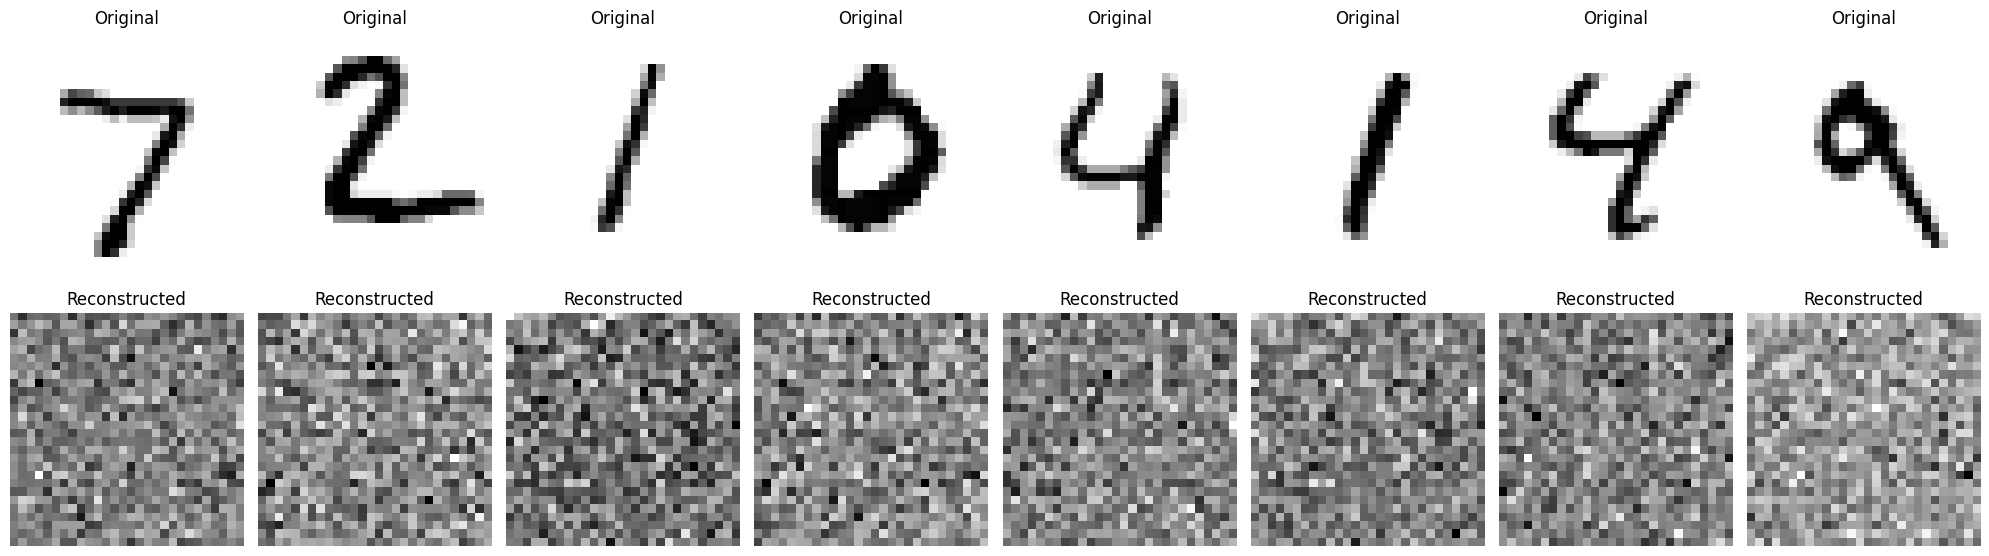

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

# ==========================================
# STEP 1: DEFINE THE ARCHITECTURE DIRECTLY
# ==========================================
# Replace this block with your actual network layers if you are not loading a file
stacked_autoencoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(30, activation="selu"),  # Central bottleneck
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])

# If you have a weights file uploaded, uncomment the next line:
# stacked_autoencoder.load_weights("my_weights.h5")


# ==========================================
# STEP 2: PLOTTING LOGIC (Will execute smoothly)
# ==========================================
preds = stacked_autoencoder.predict(x_test[:8].reshape(-1, 28, 28), verbose=0)

plt.figure(figsize=(20, 6))
for i in range(8):
    # Plot Original Image (Top Row)
    plt.subplot(2, 8, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="binary")
    plt.title("Original")
    plt.axis("off")

    # Plot Reconstructed Image (Bottom Row)
    plt.subplot(2, 8, i + 9)
    plt.imshow(preds[i].reshape(28, 28), cmap="binary")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()




In [15]:
# Denosing autoencoder
import numpy as np

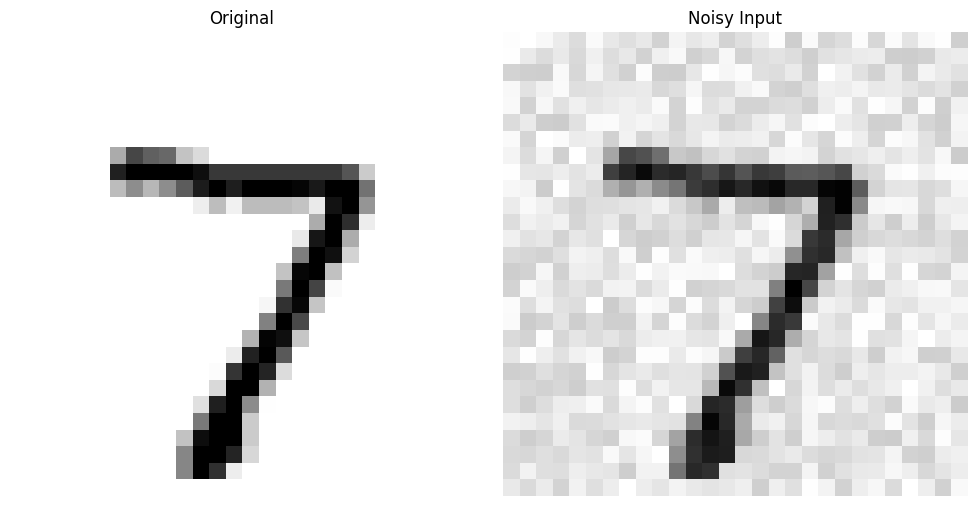

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Fixed figure syntax and swapped dimensions to (10, 5) so images aren't stretched vertically
plt.figure(figsize=(10, 5))

# 2. Added plt. prefix for the first subplot
plt.subplot(1, 2, 1)
plt.imshow(x_test[0].reshape(28, 28), cmap="binary")
plt.title("Original")
plt.axis("off")

# 3. Added plt. prefix for the second subplot
plt.subplot(1, 2, 2)

# 4. Fixed random noise generation function syntax
noise = np.random.rand(28, 28) / 4

# 5. Added plt. prefix and ensured proper shape matching for the addition
plt.imshow(x_test[0].reshape(28, 28) + noise, cmap="binary")
plt.title("Noisy Input")
plt.axis("off")

plt.tight_layout()
plt.show()
